In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from src.database.connection import get_db_engine

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Extracción de datos
engine = get_db_engine()
query = "SELECT CustomerID, Recency, Frequency, Monetary_Volume, Avg_Account_Balance FROM vw_RFM_Matrix;"
df = pd.read_sql(query, con=engine)
df.set_index('CustomerID', inplace=True)

# Limpieza inicial
df.dropna(inplace=True)
df = df[(df >= 0).all(axis=1)]

print("Dimensiones de la matriz:", df.shape)
df.describe().round(2)

Dimensiones de la matriz: (882600, 4)


,Recency,Frequency,Monetary_Volume,Avg_Account_Balance
count,882600.00,882600.00,882600.00,8.826000e+05
mean,55.30,1.19,1866.94,1.151579e+05
std,15.23,0.45,7207.64,8.012311e+05
min,0.00,1.00,0.00,0.000000e+00
25%,43.00,1.00,200.00,5.590570e+03
50%,55.00,1.00,537.00,1.871484e+04
75%,68.00,1.00,1500.00,6.177764e+04
max,81.00,6.00,1560034.99,1.150355e+08


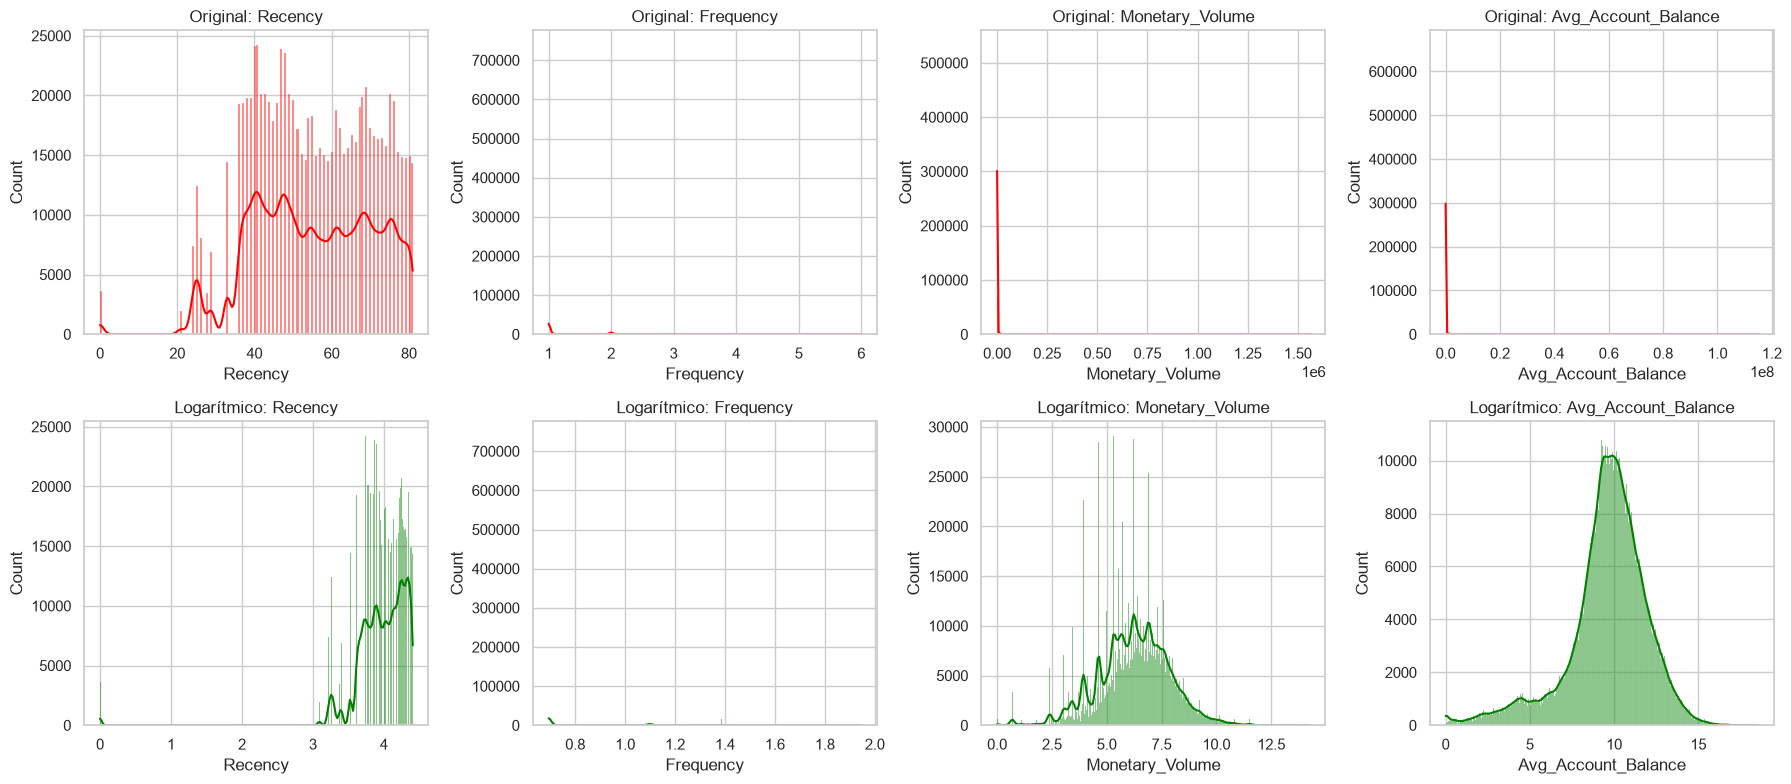

In [5]:
# Gráfica de comparación de distribuciones
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Datos Crudos
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color='red')
    axes[0, i].set_title(f'Original: {col}')

# Datos con Transformación Logarítmica
df_log = np.log1p(df)
for i, col in enumerate(df_log.columns):
    sns.histplot(df_log[col], kde=True, ax=axes[1, i], color='green')
    axes[1, i].set_title(f'Logarítmico: {col}')

plt.tight_layout()
plt.show()

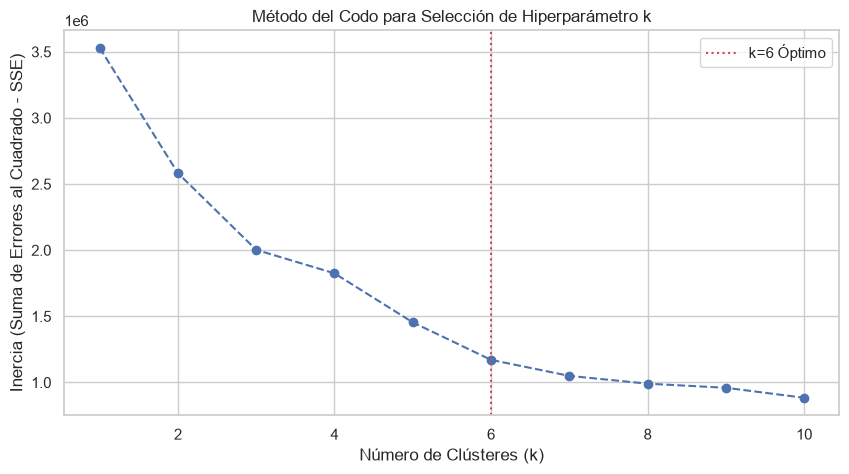

In [6]:
# Estandarización
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_log), columns=df_log.columns, index=df_log.index)

# Cálculo de Inercia
sse = {}
for k in range(1, 11):
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init='auto')
    kmeans.fit(df_scaled)
    sse[k] = kmeans.inertia_

# Gráfica del Codo
plt.figure(figsize=(10, 5))
plt.plot(list(sse.keys()), list(sse.values()), marker='o', linestyle='--', color='b')
plt.axvline(x=6, color='r', linestyle=':', label='k=6 Óptimo')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia (Suma de Errores al Cuadrado - SSE)')
plt.title('Método del Codo para Selección de Hiperparámetro k')
plt.legend()
plt.show()

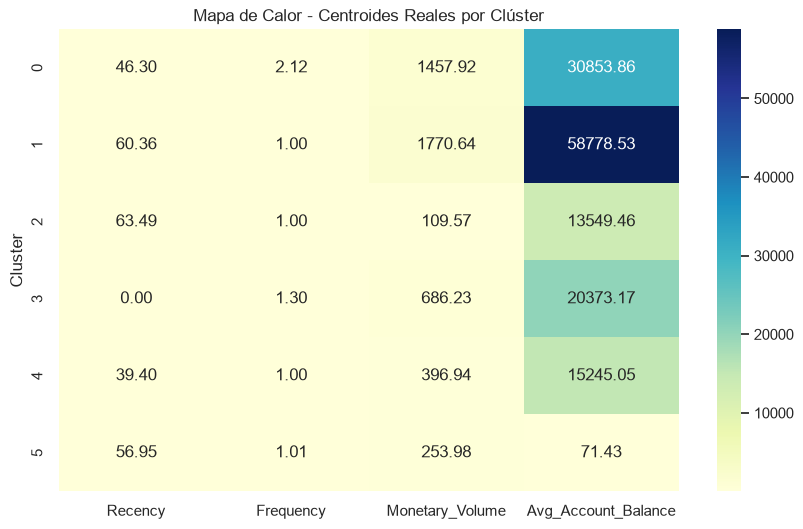

In [7]:
# Entrenamiento k=6
kmeans_final = MiniBatchKMeans(n_clusters=6, random_state=42, batch_size=10000, n_init='auto')
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

# Obtención de Centroides Reales
centroids_scaled = kmeans_final.cluster_centers_
centroids_log = scaler.inverse_transform(centroids_scaled)
centroids_real = pd.DataFrame(np.expm1(centroids_log), columns=df_log.columns)
centroids_real.index.name = 'Cluster'

# Mapa de Calor de Centroides
plt.figure(figsize=(10, 6))
sns.heatmap(centroids_real, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Mapa de Calor - Centroides Reales por Clúster")
plt.show()